# LTAT.02.006 Andmeteaduse meetodid, sügis 2025
# 4. kodutöö

## Tähtaeg: esmaspäev, 10. november, kell 12:00 (keskpäeval)

### Kodutöö reeglid

Palun kontrollige üle kodutööde reeglid esimesest kodutööst, samad reeglid kehtivad siin.

### Palun lugege kokku kodutööle kulunud aeg

Palun, et loeksite kokku kodutööle kulunud aeg, eriti hea kui ka eraldi iga ülesande peale kulunud aeg. Eraldi ülesannete alapunktide kaupa pole aega vaja eristada. Kulunud aeg kirjutage palun selleks mõeldud lahtritesse kodutöö lõpus. See ei ole kohustuslik ega mõjuta hinnet, kuid aitab kodutöid paremaks teha.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
import scipy.stats

import warnings

# Scipy funktsioon confusion_matrix viskab hoiatusi kui klasside arv läheb liiga suureks
# Selles kodutöös ignoreerime neid hoiatusi
warnings.filterwarnings("ignore", message="The number of unique classes*")

# 1. ülesanne.  Käsitsi kirjutatud numbri tuvastus: K-keskmiste meetod (3 punkti)

Käsitsi kirjutatud teksti või numbrite tuvastamiseks kasutatakse mudeleid, mis on tüüpiliselt treenitud masinõppe meetoditega suurel hulgal märgendatud andmetel. Andmete märgendamine ehk inimese poolt õige vastuse kirjapanek on aga väga töömahukas, mistõttu on masinõppe üheks suunaks leida meetodeid mudelite treenimiseks pooljuhendatud moel (semi-supervised learning). Pooljuhendatud õppe korral on märgendatud vaid väike osa treeningandmestikust ning ülejäänud treeningandmestiku puhul ei saa õppimisalgoritm õiget vastust ette. K-keskmiste meetodit ja Gaussi segumudeleid saab rakendada pooljuhendatud õppeks ning seda käesolevas kodutöös teemegi.

Vaatleme andmestikku käsitsi kirjutatud numbritest 0,1,2,...,9. Igaks juhuks segame andmestiku juhuslikult ära, et treening ja testandmestiku valik saaks juhuslik. Esimesed 1000 numbripilti võtame treeningandmestikuks ja ülejäänud 797 võtame testandmestikuks. NB! Kodutöö lahendustes võib testandmestikku kasutada ainult seal kus seda on nõutud (et näiteks mitte kogemata treenida testandmestikul). Seejuures kustutame enamike treeningandmestiku piltide kohta info selle kohta, mis on õige märgend ja alles jätame märgendi vaid igast erinevast numbrist (0-9) kõige esimesel 3 pildil.

In [2]:
pildiandmestik = load_digits()
kõik_pildid = pildiandmestik.data
kõik_märgendid = pildiandmestik.target

np.random.seed(0)
uus_järjekord = np.arange(len(kõik_pildid))
np.random.shuffle(uus_järjekord)
kõik_pildid = kõik_pildid[uus_järjekord]
kõik_märgendid = kõik_märgendid[uus_järjekord]

treen_pildid = kõik_pildid[:1000]
TEST_pildid = kõik_pildid[1000:]
treen_märgendid = kõik_märgendid[:1000]
TEST_märgendid = kõik_märgendid[1000:]

mitu_märgendatud = 10*[0]
treen_märgendite_indeksid = []
for i in range(len(treen_märgendid)):
    if mitu_märgendatud[treen_märgendid[i]]==3:
        treen_märgendid[i] = -99999 # numpy integer-massiivides ei ole NaN väärtust, seepärast kasutame -99999
    else:
        mitu_märgendatud[treen_märgendid[i]] += 1
        treen_märgendite_indeksid.append(i)

treen_märgendite_indeksid = np.array(treen_märgendite_indeksid)
märgendatud_treen_pildid = treen_pildid[treen_märgendite_indeksid]
treen_märgendid = treen_märgendid[treen_märgendite_indeksid]

print(f"Treeningandmestiku suurus: {treen_pildid.shape=}")
print(f'Märgendatud pilte on treeningandmestikus {len(treen_märgendite_indeksid)} ja nende positsioonid on järgmised:')
print("Positsioonid:")
print(treen_märgendite_indeksid)
print("Märgendid:")
print(treen_märgendid)
print("Esimesed 3 märgendatud pilti:")
print(märgendatud_treen_pildid[:3])

Treeningandmestiku suurus: treen_pildid.shape=(1000, 64)
Märgendatud pilte on treeningandmestikus 30 ja nende positsioonid on järgmised:
Positsioonid:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 16 17 18 21 23 24 25 26 27 29 30
 36 37 38 45 59 62]
Märgendid:
[2 8 2 6 6 7 1 9 8 5 2 8 6 1 0 5 7 4 7 5 4 9 9 4 3 1 0 0 3 3]
Esimesed 3 märgendatud pilti:
[[ 0.  0. 11. 16. 15.  3.  0.  0.  0.  5. 16. 12. 11. 13.  0.  0.  0.  3.
  13.  1.  5. 15.  0.  0.  0.  0.  0.  0. 12. 11.  0.  0.  0.  0.  0.  1.
  16.  7.  0.  0.  0.  0.  0. 10. 15.  0.  0.  0.  0.  0. 12. 16. 16. 11.
   1.  0.  0.  0. 13. 13.  8. 13. 16.  8.]
 [ 0.  1. 15. 14.  2.  0.  0.  0.  0.  6. 14.  0.  0.  3.  2.  0.  0.  2.
  16.  3.  2. 13.  3.  0.  0.  0. 11. 14. 15.  9.  0.  0.  0.  0.  7. 16.
  11.  0.  0.  0.  0.  0. 15. 13. 14.  0.  0.  0.  0.  2. 15.  4. 16.  3.
   0.  0.  0.  1. 15. 16. 12.  1.  0.  0.]
 [ 0.  2. 13. 16. 10.  0.  0.  0.  0. 12. 15.  9. 16.  2.  0.  0.  0. 10.
   8.  1. 16.  6.  0.  0.  0.  1.  1.  2. 16.  6.

Massiiv `treen_pildid` sisaldab nüüd 1000 käsitsi kirjutatud numbrit, igaüks on esitatud 64-elemendilise vektorina täisarvudest 0,1,...,15. Iga arv tähistab pikseli värvi, kus 15 on must, 0 on valge ja vahepealsed arvud on halltoonid nende vahel. Märgendatud treeningpildid on massiivis `märgendatud_treen_pildid`, selles on 30 64-elemendilist vektorit. Üksikut numbrit (näiteks indeksil 5) saab visualiseerida nii:

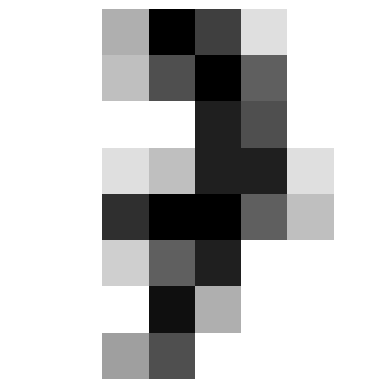

In [55]:
plt.imshow(märgendatud_treen_pildid[5].reshape(8, 8), cmap='binary')
plt.axis('off')
plt.xticks(range(8))
plt.yticks(range(8))
plt.show()

Nagu näha, on tegemist vaid 8x8 pikseli suuruse pildiga. Selline pilt on saadud algselt suurema lahutusega pildist  ning näib sellisena väga kandiline, hall ja raskesti äratuntav. Meie nägemise eripärade tõttu on aga täpselt sama pilti väiksemana üles joonistades tulemus loomulikum ja isegi lihtsamini äratuntav:

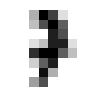

In [56]:
plt.figure(figsize=(1,1))
plt.imshow(märgendatud_treen_pildid[5].reshape(8, 8), cmap='binary')
plt.axis('off')
plt.xticks([])
plt.yticks([])
plt.show()

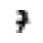

In [57]:
plt.figure(figsize=(0.3,0.3))
plt.imshow(märgendatud_treen_pildid[5].reshape(8, 8), cmap='binary')
plt.axis('off')
plt.xticks([])
plt.yticks([])
plt.show()

Märgendatud treeningpiltide märgendid on toodud massiivis `treen_märgendid`. Näiteks ülaltoodud pildi märgend on järgmine:

In [58]:
treen_märgendid[5]

np.int64(7)

Piltide mugavamaks joonistamiseks on siin sobiv funktsioon:

In [ ]:
def joonista(pildid, suurus=0.3, veerge=1):
    ridu = int(np.ceil(len(pildid)/veerge))
    fig, axs = plt.subplots(ridu, veerge, figsize=(veerge*suurus,ridu*suurus), subplot_kw=dict(xticks=[],yticks=[]))
    fig.subplots_adjust(hspace=0.1, wspace=0.1)

    for i in range(len(pildid)):
        ax = axs.flat[i]
        ax.imshow(pildid[i].reshape(8, 8), cmap='binary')
        ax.axis("off")
    
    plt.show()

Mudeli treenimiseks on meil nüüd siis kasutada 970 märgendamata pilti ja 30 märgendatud pilti. Esimesed 200 märgendamata pilti on siin:

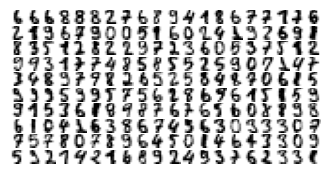

In [59]:
mitte_märgendatud_indeksid = np.delete(range(len(treen_pildid)), treen_märgendite_indeksid)
joonista(treen_pildid[mitte_märgendatud_indeksid[:200]], suurus=0.2, veerge=20)

Ja kõik 30 märgendatud pilti on siin:

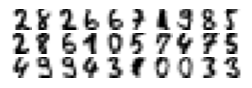

[[2 8 2 6 6 7 1 9 8 5]
 [2 8 6 1 0 5 7 4 7 5]
 [4 9 9 4 3 1 0 0 3 3]]


In [60]:
joonista(märgendatud_treen_pildid,veerge=10)
print(treen_märgendid.reshape(3,10))

<font color='purple'>**(1a) Mida teeb järgnevatel ridadel `.reshape(8,8)`? Millise rea ja millise veeru pikslit tähistab massiivis `treen_pildid[5]` kohal 30 paiknev väärtus?** (Küsin seda, sest on oluline, et saaksite täpselt aru pildi esitusest ühemõõtmelise massiivina ehk vektorina.)</font>
    
<font color='purple'>**OODATUD VASTUS: Selgitus 1-2 lauset.**</font>

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [51]:
treen_pildid[5]

array([ 0.,  0.,  5., 16., 12.,  2.,  0.,  0.,  0.,  0.,  4., 11., 16.,
       10.,  0.,  0.,  0.,  0.,  0.,  0., 14., 11.,  0.,  0.,  0.,  0.,
        2.,  4., 14., 14.,  2.,  0.,  0.,  0., 13., 16., 16., 10.,  4.,
        0.,  0.,  0.,  3., 10., 14.,  0.,  0.,  0.,  0.,  0.,  0., 15.,
        5.,  0.,  0.,  0.,  0.,  0.,  6., 11.,  0.,  0.,  0.,  0.])

In [52]:
treen_pildid[5].reshape(8,8)

array([[ 0.,  0.,  5., 16., 12.,  2.,  0.,  0.],
       [ 0.,  0.,  4., 11., 16., 10.,  0.,  0.],
       [ 0.,  0.,  0.,  0., 14., 11.,  0.,  0.],
       [ 0.,  0.,  2.,  4., 14., 14.,  2.,  0.],
       [ 0.,  0., 13., 16., 16., 10.,  4.,  0.],
       [ 0.,  0.,  3., 10., 14.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 15.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  6., 11.,  0.,  0.,  0.,  0.]])

In [53]:
treen_pildid[5][30]

np.float64(2.0)

<font color='red'>Vastus:</font> ...

<font color='purple'>**(1b) Enne kui pooljuhendatud õppe juurde asume, vaatame mida saab saavutada juhendatud õppe meetoditega, mis kasutavad õppimiseks vaid märgendatud andmeid, ehk antud juhul vaid 30 märgendatud pilti. Otsustusmets (random forest) ja K lähima naabri meetod (KNN, K-Nearest Neighbours) on ühed masinõppe meetodid, mis töötavad üpriski edukalt ka väikeste andmestikega.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Treenige otsustusmets ja KNN vaikeparameetritega ja mõõtke nende ennustuste täpsus (accuracy) testandmetel.**</font>

2. <font color='purple'>**Mõlema mudeli puhul võrrelge testandmetel ennustusi tegelike  märgenditega kasutades funktsiooni `confusion_matrix` (NB! pöörake argumentide järjekorrale tähelepanu) ning kirjeldage mis numbreid need mudelid kõige sagedamini omavahel sassi ajavad.**</font>

3. <font color='purple'>**Seejuures kasutage andmeid `TEST_pildid` ja `TEST_märgendid` ainult juba sobitatud mudelite ennustuste täpsuse mõõtmisel.**</font>

<font color='purple'>**OODATUD VASTUS: Otsustusmetsa ja KNN täpsus ja segadusmaatriksid ja selgitus, mis numbreid omavahel segi ajavad. Lisaks selgitus selle kohta, kas nii hea/halb täpsus oli teile isiklikult oodatav.**</font>

VIHJE:
* Tutvuge funktsiooniga `accuracy_score` ja klassiga `KNeighborsClassifier` (kasutatav sarnaselt klassile `RandomForestClassifier`).

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

Siin on kood, mis treenib otsustuspuu ja teeb selle abil ennustused testandmetele:

In [ ]:
rf = RandomForestClassifier(random_state = 0).fit(märgendatud_treen_pildid, treen_märgendid)
TEST_ennustused = rf.predict(TEST_pildid)

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(1c) Hakkame pilte klasterdama ja valime sobiva klastrite arvu.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**K-keskmiste meetodil (mitte sassi ajada K lähima naabri meetodiga) klasterdada andmestik `treen_pildid`. Seejuures valida parim K küünarnukimeetodil väärtuste K=1,2,...,50 seast.**</font>

2. <font color='purple'>**Kui K juhtub tulema väiksem kui 5, siis valige K=5 (järgmiste alamülesannete huvides).**</font>

3. <font color='purple'>**Samuti kui K juhtub tulema suurem kui 20, siis valige K=20.**</font>

4. <font color='purple'>**Välja valitud K korral trükkida välja kõigi 30 märgendatud treeningandmepunkti kohta, et mis numbriga klastrisse nad kuuluvad. Kas sama märgendiga treeningandmepunktid satuvad enamasti pigem samasse või erinevasse klastrisse?**</font>

<font color='purple'>**OODATUD VASTUS: Valitud K väärtus; 30 märgendatud treeningandmepunkti klastrinumbrid; selgitus 1-3 lauset, kas pigem satuvad sama märgendiga pildid samasse või erinevasse klastrisse.**</font>    
    
VIHJE:
* Uurige `KMeans` objekti atribuuti `labels_`. 
* Andmestik `treen_pildid` sisaldab kõiki treeeningpilte, neist märgendatud piltide indeksid on massiivis `treen_märgendite_indeksid`. 

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(1d) Joonistage 8x8 piltidena välja eelmise punkti lõpuks leitud klasterduse klastrite keskpunktid, kasutades ülaltoodud funktsiooni `joonista`. Keskpunktid saab kätte funktsiooni `KMeans` väljastatud objekti atribuudina `cluster_centers_`. Selgitage, kas nende piltide pealt on näha põhjuseid, miks eelmises punktis (1c) sama märgendiga treeningandmepunktid sattusid või ei sattunud erinevatesse klastritesse.**</font>
    
<font color='purple'>**OODATUD VASTUS: Joonis ja selgitus 2-5 lauset.**</font>

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(1e) JUHISED:**</font>
1. <font color='purple'>**Arvutada funktsiooni `confusion_matrix` abil välja tabel 30 märgendatud pildi kohta, kus**</font>
    * <font color='purple'>**Ridadeks on tegelikud märgendid ja veergudeks on klastrite numbrid (sama klasterdusega saadud, mille alapunktis (1c) leidsite).**</font>
    * <font color='purple'>**Iga arv tabeli i-ndas reas ja j-ndas veerus näitab, mitu märgendiga i pilti on sattunud klastrisse j.**</font>
    * <font color='purple'>**Kontrollida hoolikalt, et ridade ja veergude tähendused vahetusse ei läheks. Ärge laske ennast segada sellest, et kui ridu ja veerge peaks tulema erinev arv, siis `confusion_matrix` lisab ise vastavalt juurde nullide ridu või veerge, et kokku tuleks ruutmaatriks.**</font>
2. <font color='purple'>**Trükkige print-käsuga saadud tabel.**</font>
3. <font color='purple'>**Kirjutada funktsioon `def klastri_sagedaseim_märgend(m):`**</font>
    * <font color='purple'>**Saab ette selle tabeli (mille `confusion_matrix` väljastas) ning väljastab 1-mõõtmelise numpy massiivi, kus kohal i on klastri i kõige sagedasem märgend.**</font>
    * <font color='purple'>**Kui mitu märgendit on sama sagedusega, siis valige ise milline neist väljastada (näiteks järjekorras esimene).**</font>
    * <font color='purple'>**Kui klastris pole ühtki märgendatud andmepunkti, siis väljastage näiteks märgend 0 (või mõni muu kui soovite).**</font>
4. <font color='purple'>**Salvestage muutujasse `klastrist_märgendiks` tulemusmassiiv, mille saate kui rakendate 30 märgendatud pildile funktsiooni `confusion_matrix` ja sellele omakorda enda funktsiooni `klastri_sagedaseim_märgend`.**</font>
5. <font color='purple'>**Trükkige print-käsuga `klastrist_märgendiks` välja.**</font>

<font color='purple'>**OODATUD VASTUS: Funktsiooni `confusion_matrix` tulemus 30 märgendatud pildil; massiivi `klastrist_märgendiks` väljatrükk.**</font>

VIHJE:
* Uurige, mida teeb `m.argmax(axis=0)`, kus `m` on tabel, mille on väljastanud `confusion_matrix`. NB! Veenduge, et `confusion_matrix` funktsioonile on argumendid ette antud õiges järjekorras.
* 1-mõõtmelise numpy massiivi tegemiseks võib näiteks kõigepealt teha tavalise listi ja siis rakendada sellele `np.array(...)`.
* Funktsioonil `confusion_matrix` on valikuline argument `labels`. Selle väärtuseks tuleb määrata `range(max(10, K))`, kus `K` on valitud mudeli klastrite arv.

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='purple'>**(1f) Eelmises alapunktis (1e) saadud massiivi `klastrist_märgendiks` saab kasutada kui ennustusmeetodit, mis ennustab pildi märgendit selle järgi, mis numbriga klastrisse see pilt kuulub. Ehk klastrisse `i` kuuluvale pildile tuleks ennustuseks märgend `klastrist_märgendiks[i]`.**</font>

<font color='purple'>**JUHISED:**</font>
1. <font color='purple'>**Leidke TEST-piltidele klastri numbrid, kasutades funktsiooni `KMeans` väljastatud objekti meetodit `predict` (sama klasterdus, mis saadi punktis 1c). Selle tulemusena saab iga test-pilt sinna klastrisse, mille keskpunkt talle kõige lähemal on.**</font>
2. <font color='purple'>**Kasutage massiivi `klastrist_märgendiks`, et saada TEST-pildi klastrinumbri järgi ennustus selle kohta, mis võiks olla selle pildi õige märgend.**</font>
2. <font color='purple'>**Tehke sellisel meetodil ennustus kõigile TEST-piltidele ja võrreldes ennustusi tegelike märgenditega mõõtke sellise meetodi ennustustäpsus (accuracy).**</font>
2. <font color='purple'>**Uurige TEST-piltidel arvutatud segadusmaatriksi abil, milliseid numbreid see meetod omavahel sassi ajab. Kas sassiajamise põhjuseid on näha ka punktis (1d) välja joonistatud klastrite keskpunktidest? Võrrelge täpsust otsustusmetsa ja KNN täpsusega.**</font>
    
<font color='purple'>**NB! Jälgige et read ja veerud ei läheks sassi**</font>

<font color='purple'>**OODATUD VASTUS: Saadud täpsus ja segadusmaatriks; selgitus 2-3 lauset mis numbreid meetod omavahel sassi ajab ja selle põhjuste seos klastrite keskpunktide joonistega; võrdlus otsustusmetsa ja KNN täpsusega (veel 1-3 lauset).**</font>
    
    
VIHJE:
* Täpsus peaks tulema üle 70%.

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(1g) Punktis (1c) valisime K-keskmiste meetodi parameetri K küünarnukimeetodil. Nüüd valime K hoopiski selliselt, et täpsus meie 30-pildisel märgendatud treeningandmestikul saaks võimalikult hea.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Rakendage K-keskmiste meetodit kogu treeningandmestikul erinevate K väärtuste korral: 1, 2, 3, ..., 50.**</font>

2. <font color='purple'>**Iga K väärtuse korral leidke sama meetodiga nagu punktides (1e) ja (1f) ennustused märgendatud treeningpiltidele. Ehk kõigepealt leiate klastri numbri ja siis selles klastris kõige sagedasema märgendi ning ennustate seda.**</font>

3. <font color='purple'>**Tehke joonis, kus x-teljel on K väärtused ning y-teljel ennustustäpsus märgendatud treeningandmestikul.**</font>

4. <font color='purple'>**Kõigi K väärtuste seast leidke selline, mille tulemusena saate treeningandmestikul parima ennustustäpsuse. Kui mitme K korral on ennustustäpsus sama, siis valige vähim selline K (lootuses, et sel juhul on kõige vähem ülesobitamist).**</font>
    
5. <font color='purple'>**Valitud K korral tehke ennustus TEST-piltidele ja mõõtke ennustustäpsus. Võrrelge tulemust eelmistes punktides leitud täpsustega.**</font>
    
<font color='purple'>**OODATUD VASTUS: Joonis; valitud klastrite arv K; täpsus testhulgal; selgitus, mis võrdleb tulemust eelmistes punktides leitud täpsustega (1-3 lauset).**</font>
    
VIHJE:
* Jälgige segadusmaatriksi argumente!
* Jälgige, et valik saaks tehtud treeningandmete peal!
* Jälgige, et `confusion_matrix` funktsioonis `labels` parameeter saaks korrektne!

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(1h) Mõnikord saavad K-keskmiste meetodi tulemused paremad siis kui enne klasterdamist kasutada mõõtmete vähendamiseks peakomponentanalüüsi (PCA, [principal component analysis](https://et.wikipedia.org/wiki/Peakomponentide_analüüs)).**</font>

<font color='purple'>**Etteantud kood rakendab treeningandmetele peakomponentanalüüsi, seejuures alles jättes parasjagu niipalju peakomponente, mis kokku kirjeldavad 75% andmete varieeruvusest (75% on siin laest võetud arv). Tulemus salvestatakse massiivi `treen_pildid_pca`.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**PCA tulemusena oleme algsest 64 tunnusest konstrueerinud peakomponentide näol väiksema hulga uusi tunnused. Mitu peakomponenti kasutusele võtsime?**</font>
    
2. <font color='purple'>**Rakendage sama metoodikat nagu punktis (1g), aga mitte andmetele `treen_pildid`, vaid andmetele `treen_pildid_pca`. Teisisõnu, rakendage K-keskmiste meetodit, valides K ennustuste täpsuse järgi märgendatud treeningandmestikul.**</font>

3. <font color='purple'>**Leidke ennustused TEST-andmetele, kuid seejuures ärge unustage, et test-andmetele peate ka enne rakendama teisendust `pca.transform` (kuid sobitamist funktsiooniga `fit` ei tohi test-andmetele rakendada, sest see annaks meile hoopis uue teisenduse, millele meie K-keskmiste meetodi klastrikeskpunktid ei klapiks).**</font>

4. <font color='purple'>**Leidke meetodi täpsus test-andmetel, arvutage segadusmaatriks, kommenteerige selle järgi mudeli vigu. Võrrelge täpsust eelmiste meetoditega.**</font>
    
<font color='purple'>**OODATUD VASTUS: Peakomponentide arv; saadud täpsus ja segadusmaatriks ning täpsuse võrdlus eelmiste meetoditega (1-3 lauset).**</font>
    
VIHJE:
* Jälgige segadusmaatriksi argumente!
* Jälgige, et valik saaks tehtud treeningandmete peal!
* Jälgige, et `confusion_matrix` funktsioonis `labels` parameeter saaks korrektne!

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [26]:
pca = PCA(0.75, whiten=True, random_state=0).fit(treen_pildid)
treen_pildid_pca = pca.transform(treen_pildid)
treen_pildid_pca.shape

(1000, 11)

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

# 2. ülesanne. Gaussi segumudeli uurimine (2 punkti)

K-keskmiste meetodi puhul toimub piltide vahelise kauguse mõõtmine eukleidilise kaugusmõõduga. Seetõttu ei ole selle meetodi jaoks vahet, milliste pikslite vahel erinevus on, sest loeb vaid summaarne erinevus (tõsi küll, kui enne andmetel peakomponentanalüüsi rakendada, siis uue ruumi kaugused ei vasta enam algse ruumi kaugustele). Seevastu Gaussi segumudelid modelleerivad igas komponendis eraldi kovariatsioonimaatriksit ning seetõttu muutub tõenäosus komponenti kuuluda rohkem või vähem sõltuvalt milliseid pikseleid muuta. Seepärast proovimegi eelmise ülesande jätkuna samal andmestikul rakendada Gaussi segumudeleid.

<font color='purple'>**(2a) Nagu K-keskmiste meetodit, nii saab ka Gaussi segumudelit kasutada märgendit ennustava mudelina. Klassi `GaussianMixture` objektide meetod `predict` leiab etteantud andmepunktide tõenäosustiheduse (pdf) iga komponendi normaaljaotuse järgi eraldi ning ennustab siis märgendina komponenti, mille tõenäosustihedus oli suurim.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Sobitage (kõigile) treeningandmetele 10-komponendiline Gaussi segumudel `gmm=GaussianMixture(n_components=10,covariance_type='full').fit(treen_pildid)`.**</font>

2. <font color='purple'>**Genereerige mudelist 30 pilti funktsiooniga `gmm.sample(30)` ja joonistage need funktsiooniga `joonista`. Kas pildid paistavad olema sarnased reaalsetega?**</font>

3. <font color='purple'>**Leidke kõige esimese märgendatud treeningandmepunkti tõenäosustihedus iga komponendi normaaljaotuse järgi eraldi ning trükkige need välja.**</font>

4. <font color='purple'>**Leidke millise komponendi järgi on tõenäosustihedus suurim ning kas see klapib sellega, mida väljastab `predict` meetod sellel pildil.**</font>

<font color='purple'>**OODATUD VASTUS: Genereeritud 30 pilti ja 1-2 lauset selle kohta kas on sarnased; väljastatud eri komponentide normaaljaotuste tõenäosustihedustega esimese märgendatud pildi korral; milline tihedus on suurim ning kas see klapib `predict` meetodi väljundiga (1-2 lauset).**</font>
    
VIHJE:
* `gmm.predict` tahab ette saada massiivi piltidest, nii et üksiku pildi korral tuleb teha ühe-elemendiline massiiv.
* Segumudeli komponendi i normaaljaotuse saab kätte nii: `scipy.stats.multivariate_normal(mean=gmm.means_[i],cov=gmm.covariances_[i])`.

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [29]:
gmm = GaussianMixture(n_components=10, covariance_type='full', random_state=0).fit(treen_pildid)

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(2b) Nüüd sobitame diagonaalse Gaussi segumudeli 10 komponendiga ning vaatleme ühte komponenti lähemalt. Diagonaalne segumudel tähendab seda, et kõik komponendid on normaaljaotused, mille kovariatsioonimaatriksis on kõik diagonaalivälised elemendid nullid. Teisisõnu, mudel vaatleb iga komponendi sees kõiki tunnuseid paarikaupa sõltumatutena. See tähendab meie ülesande puhul, et komponendi sees on iga piksli jaotus teistest pikslitest sõltumatu normaaljaotus.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Vaatleme täpsemalt komponenti, mis sisaldab valdavalt numbreid 6. Kuna juhuarvugeneraator on lähtestatud (seda teeb `random_state=0`), siis peaks see olema komponent indeksiga 3. Kui teil mingil põhjusel see komponent ei sisalda numbreid 6, siis otsige komponent, mis sisaldab, ning muutke `valitud_komponent` väärtus selle komponendi järjekorranumbriks.**</font>

2. <font color='purple'>**Nagu normaaljaotuse puhul ikka, on mudeli järgi kõige tõenäolisem andmepunkt selle normaaljaotuse keskpunkt, mis on 64-elemendiline vektor. Kasutades funktsiooni `plt.imshow(..., cmap='binary')` joonistage see keskpunkt 8x8 pildina.**</font>

3. <font color='purple'>**Joonistage selle komponendi `valitud_komponent` kovariatsioonimaatriks (mõõtmetega 64x64).**</font>    
    
4. <font color='purple'>**Esitage komponendi `valitud_komponent` kovariatsioonimaatriksi diagonaal 64-elemendilise vektorina (näiteks kasutades `np.diag(...)`) ja seejärel joonistage see üles 8x8 pildina. Leidke 3 kõige suurema varieeruvusega pikslit, mitmendas reas ja mitmendas veerus need pildil asuvad? Kas see on ootuspärane, arvestades et üldiselt vastab komponent numbrile 6?**</font>
    
<font color='purple'>**OODATUD VASTUS: Keskpunkti joonis (8x8 pildina); valitud komponendi kovariatsioonimaatriksi joonis (64x64); kovariatsioonimaatriksi diagonaal (8x8 pildina), kõige suurema varieeruvusega pikslite asukohad ja selgitus, kas ootuspärane (1-3 lauset).**</font>

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

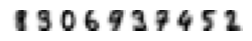

In [61]:
gmm = GaussianMixture(n_components=10, covariance_type='diag', random_state=0).fit(treen_pildid)
# sellest väljundist tuleb valida `valitud_komponent` muutuja
joonista(gmm.means_, veerge=10)

In [ ]:
valitud_komponent = 3 # kui selles komponendis pole põhiliselt numbrid 6, siis muutke
jaotus = scipy.stats.multivariate_normal(
    mean = gmm.means_[valitud_komponent], 
    cov = gmm.covariances_[valitud_komponent]
)
print(jaotus.mean.round(2))

[ 0.    0.    1.   10.79  9.79  1.45  0.    0.    0.    0.03  6.78 14.42
  6.48  0.67  0.    0.    0.    0.65 12.26  9.63  0.92  0.    0.    0.
  0.    1.99 13.42  8.11  3.53  1.62  0.06  0.    0.    3.08 14.62 13.13
 12.75 10.7   2.56  0.    0.    1.73 14.35 10.68  5.23  9.93  9.5   0.17
  0.    0.11  9.9  12.45  5.02 10.79 11.26  0.64  0.    0.    1.27 10.37
 15.08 13.24  4.85  0.15]


In [48]:
print(jaotus.cov.round(2))

[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    2.65 ...  0.    0.    0.  ]
 ...
 [ 0.    0.    0.   ...  7.02  0.    0.  ]
 [ 0.    0.    0.   ...  0.   15.88  0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.52]]


In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(2c) Uurime, kuidas mõjutab kovariatsioonimaatriks segumudelit.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Sobita kaks Gaussi segumudelit, üks diagonaalne (parameetriga `covariance_type='diag'`) ja teine tavaline ehk täis-kovariatsioonimaatriksiga (`covariance_type='full'`). Lähtesta mõlema sobitamiseks juhuarvugeneraator (`random_state=0`) ja tuvasta kummalgi mudelil komponent, mis sisaldab numbrit 6.**</font>

2. <font color='purple'>**Leia mõlema mudeli jaoks treeningandmestikust pildid, millele see mudel ennustab arvule 6 vastavat komponenti. Salvesta need pildid eraldi numpy massiividesse.**</font>

3. <font color='purple'>**Genereeri mõlema mudeli arvule 6 vastavast komponendist nii palju pilte, kui palju vastav mudel ennustas treeningandmestiku pilte sellesse komponenti. Joonista mõlemad genereeritud andmestikud.**</font>

4. <font color='purple'>**Vaatleme iga pildi kõige alumise rea 6. ja 7. veeru pikslit ehk piksleid indeksitega 61 ja 62 (sest indeksid algavad 0-st). Tehke neli hajuvusdiagrammi (scatterplot) nende pikslite kui tunnuste ühisjaotusest: kaks joonist nendest piltidest, mida kumbki mudel ennustas arvuks 6 ning kaks pilti mõlemast mudelist genereeritud piltidest.**</font>

<font color='purple'>**OODATUD VASTUS: Kaks joonist genereeritud piltidega (diagonaalne vs tavaline mudel); neli hajuvusdiagrammi pikslite 61 ja 62 ühisjaotusest**</font>

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

<font color='purple'>**(2d) Arutlege Gaussi segumudelite sobivuse ja kasulikkuse üle käsitsi kirjutatud numbrite tuvastamise ja genereerimise ülesannetes.**</font>
    
<font color='purple'>**OODATUD VASTUS: Arutlus (5-10 lauset).**</font>

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

<font color='red'>Vastus:</font> ...

# Boonusülesanne. Käsitsi kirjutatud numbrite tuvastus Gaussi segumudeliga (1 punkt)

<font color='purple'>**1. ülesandes tegime pooljuhendatud õpet K-means klasterduse abil ning proovisime ka enne klasterdust rakendada dimensioonide vähendust PCA abil. Ka Gaussi segumudelit saab kasutada klasterdusmeetodina, kus klastriteks on komponendid. Eelnevalt valisime peakomponentanalüüsi komponentide arvu üsna suvaliselt. Nüüd uurime, kas suudame komponentide arvu valida eesmärgist lähtuvalt.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Proovige läbi kõik 400 kombinatsiooni peakomponentide arvust 1,2,...,20 ja Gaussi segumudeli komponentide arvust 1,2,...,20. Kasutage nii PCA kui ka Gaussi segumudeli sobitamisel argumenti `random_state=0`.**</font>

2. <font color='purple'>**Valige parim kombinatsioon lähtuvalt ennustuste täpsuse järgi märgendatud treeningandmestikul (sama metoodika, mis ülesandes 1h, aga K-means klastrite asemel on segumudeli ennustatud komponendid). Viigi korral eelistage kombinatsiooni, milles on nii peakomponentide arv kui segumudeli komponentide arv võimalikult väiksed (näiteks olgu nende summa minimaalne).**</font>

3. <font color='purple'>**Leidke meetodi täpsus test-andmetel, arvutage segadusmaatriks, kommenteerige selle järgi mudeli vigu. Võrrelge täpsust eelmiste meetoditega.**</font>
  
<font color='purple'>**OODATUD VASTUS: Saadud täpsus ja segadusmaatriks ning täpsuse võrdlus eelmiste meetoditega.**</font>

**Küsimus praksi juhendajale:**

***TEHTUD*** : 0/1

In [ ]:
# Lahendus

<font color='red'>Vastus:</font> ...

## <font color='red'>Enne kodutöö esitamist palun lähtesta kernel uuesti ning jooksuta kogu kood algusest peale korra läbi - selleks on vaja menüüst valida `Kernel` -> `Restart and Run All`.</font>

## Kodutöö tagasiside

Palun vasta nii täpselt kui oskad. See ei muuda mingilgi moel punkte, mille kodutöö eest saad. Nii 0,5 tundi kui 24 tundi on sobivad vastused. Kogutud informatsiooni kasutatakse kodutööde paremaks muutmiseks.

<font color = "red">**Tagasidet saad anda anonüümselt siin [Google Formsis](https://forms.gle/KPD6FZ5ScUNYUdsaA).**</font>

**<font color='red'>SUUR TÄNU TEHTUD TÖÖ EEST!</font>**